<a href="https://colab.research.google.com/github/ElviraGD-lab/pajares-mountain-corridor-baseline/blob/main/notebooks/03_vegetation_cycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

Mounted at /content/drive
Environment: colab
Data folder: /content/drive/MyDrive/python-remote-sensing
Output folder: /content/drive/MyDrive/python-remote-sensing


In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray \
        dask['distributed'] jupyter-server-proxy xrscipy

In [ ]:
import dask
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
import xrscipy.signal as xrs
from odc.stac import configure_s3_access, load

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36827
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40085'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:38899'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:34901 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:34901
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43192
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35887 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35887
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43194
INFO:distributed.scheduler:Receive client connection: Client-f720343e-b006-11f1-8327-0242ac1c000c
INFO:distributed.core:Starting establish

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36827,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34901,Total threads: 1
Dashboard: http://127.0.0.1:39945/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40085,


In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

https://8787-m-s-kkb-usc1b0-zlhzul3a6stt-b.us-central1-0.prod.colab.dev


In [ ]:
# All decisions in one place. Mountainous terrain at 43 N requires
# choices the course notebook does not make.

LATITUDE = 43.0000
LONGITUDE = -5.7600
YEAR = 2023

MAX_CLOUD = 30          # scene-level filter
RESOLUTION = 10         # native Sentinel-2
TARGET_CRS = 'EPSG:25830'   # ETRS89 / UTM 30N, project standard

# SCL classes removed from the data.
#  3  cloud shadow
#  8  cloud medium probability
#  9  cloud high probability
# 10  thin cirrus
#  2  dark area -- terrain shadow. In this terrain at 43 N the sun drops
#     to 21 degrees in December and north-facing slopes fall into their
#     own shadow. Reflectance there is near zero in every band, so any
#     ratio index is dominated by noise. Excluded deliberately; see the
#     cost this carries in the count printed below.
# 11  snow / ice -- not vegetation, and Sen2Cor confuses it with cloud
#     in mountains. Excluded.
MASK_CLASSES = [2, 3, 8, 9, 10, 11]

# Outlier rejection: a closed deciduous canopy cannot change NDVI by
# more than this between consecutive observations a few days apart.
MAX_STEP = 0.25

RESAMPLE_FREQ = '5d'    # Sentinel-2 revisit with two satellites
SMOOTH_WINDOW = 3       # 3 x 5 days = 15 days

In [ ]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [LONGITUDE, LATITUDE]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{YEAR}',
    query={'eo:cloud_cover': {'lt': MAX_CLOUD}},
)
items = search.item_collection()
print(f'{len(items)} scenes found')

ds = load(
    items,
    bands=['red', 'nir', 'scl'],
    resolution=RESOLUTION,
    crs=TARGET_CRS,
    chunks={'x': 1024, 'y': 1024},
    groupby='solar_day',
)

# New name at each step: nothing is overwritten, so re-running this
# cell cannot apply the scale and offset twice.
masked_nodata = ds.where(ds != 0)

spectral = ['red', 'nir']
reflectance = masked_nodata[spectral] * 0.0001 - 0.1

cloud_mask = masked_nodata['scl'].isin(MASK_CLASSES)
clean = reflectance.where(~cloud_mask)

ndvi = (clean['nir'] - clean['red']) / (clean['nir'] + clean['red'])
ndvi = ndvi.where(np.isfinite(ndvi)).clip(-1, 1)

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


48 scenes found


In [ ]:
transformer = pyproj.Transformer.from_crs(
    'EPSG:4326', TARGET_CRS, always_xy=True)
x, y = transformer.transform(LONGITUDE, LATITUDE)
print(f'Point in {TARGET_CRS}: x={x:.0f}, y={y:.0f}')

raw = ndvi.interp(y=y, x=x, method='nearest').chunk(dict(time=-1)).compute()

print(f'Observations: {len(raw)}')
print(f'Valid after masking: {int(raw.notnull().sum())}')

Point in EPSG:25830: x=275031, y=4764512
Observations: 48
Valid after masking: 31


In [ ]:
def reject_outliers(series, max_step=MAX_STEP):
    """Remove points that jump too far from both neighbours.

    A closed canopy cannot gain or lose a quarter of its NDVI in days.
    Such a point is residual cloud, shadow or haze that the SCL mask
    missed. Rejected before smoothing, because a smoother does not
    remove an error -- it spreads it across the neighbours and makes
    it invisible.
    """
    values = series.values.copy()
    flagged = 0

    for i in range(1, len(values) - 1):
        prev_val, this_val, next_val = values[i - 1], values[i], values[i + 1]
        if np.isnan(this_val) or np.isnan(prev_val) or np.isnan(next_val):
            continue
        # A real change moves in one direction; a spike departs from both
        # neighbours and returns.
        if (abs(this_val - prev_val) > max_step
                and abs(this_val - next_val) > max_step
                and np.sign(this_val - prev_val) == np.sign(this_val - next_val)):
            values[i] = np.nan
            flagged += 1

    print(f'Rejected {flagged} spike(s)')
    return series.copy(data=values)


despiked = reject_outliers(raw)

Rejected 1 spike(s)


In [ ]:
import pandas as pd
# Sun elevation at overpass, read from scene metadata.
sun = {}
for item in items:
    date = pd.to_datetime(item.properties['datetime']).tz_localize(None).normalize()
    sun[date] = item.properties.get('view:sun_elevation')

MIN_SUN_ELEVATION = 25

dates = pd.to_datetime(despiked.time.values).normalize()
low_sun = np.array([
    (sun.get(d) is not None and sun[d] < MIN_SUN_ELEVATION) for d in dates])

print(f'Observations below {MIN_SUN_ELEVATION} deg sun: {low_sun.sum()}')

filtered = despiked.where(~xr.DataArray(low_sun, dims='time'))
print(f'Valid after all filters: {int(filtered.notnull().sum())}')

missing = [d for d in dates if d not in sun]
if missing:
    print(f'WARNING: no sun elevation for {len(missing)} date(s): {missing[:3]}')

Observations below 25 deg sun: 8
Valid after all filters: 28


In [ ]:
resampled = filtered.resample(time=RESAMPLE_FREQ).mean(dim='time')

# Interpolate between known values only. No bfill or ffill: filling the
# ends copies a value into a period where nothing was observed, which
# is extrapolation disguised as data.
interpolated = resampled.interpolate_na('time', use_coordinate=True)

print(f'Grid cells: {len(interpolated)}')
print(f'Filled:     {int(interpolated.notnull().sum())}')
print(f'Still NaN:  {int(interpolated.isnull().sum())}  (honest gaps)')

Grid cells: 72
Filled:     47
Still NaN:  25  (honest gaps)


In [ ]:
smoothed = interpolated.rolling(
    time=SMOOTH_WINDOW, min_periods=2, center=True).mean()

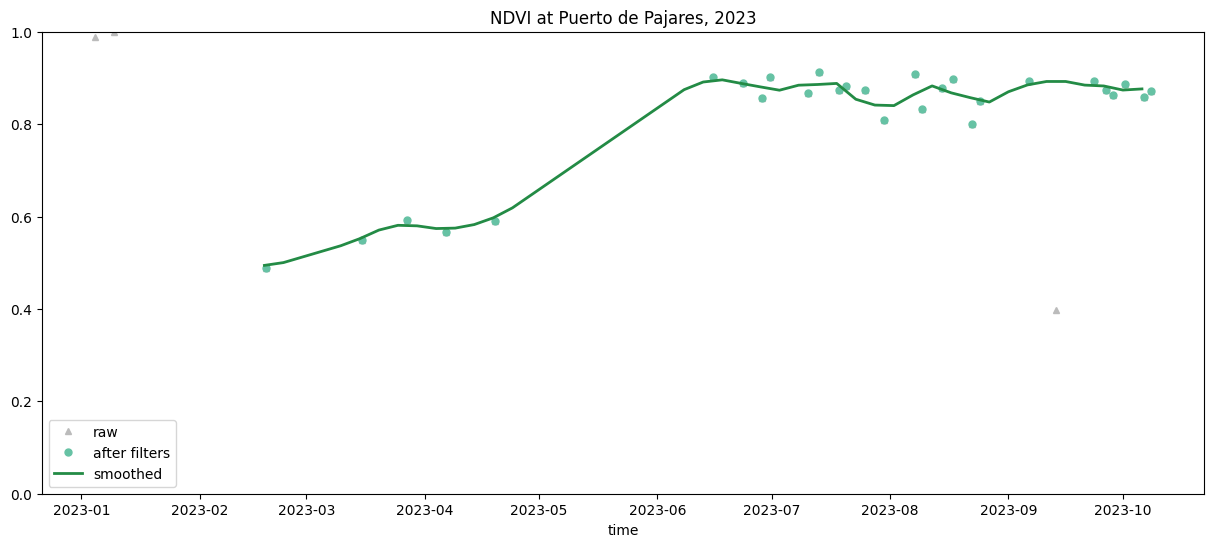

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 6)

raw.plot.line(ax=ax, x='time', marker='^', markersize=4,
              color='#bbbbbb', linestyle='none', label='raw')
filtered.plot.line(ax=ax, x='time', marker='o', markersize=5,
                   color='#66c2a4', linestyle='none', label='after filters')
smoothed.plot.line(ax=ax, x='time', marker='', linewidth=2,
                   color='#238b45', label='smoothed')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.set_ylim(0, 1)
ax.set_title(f'NDVI at Puerto de Pajares, {YEAR}')
ax.legend()
plt.show()

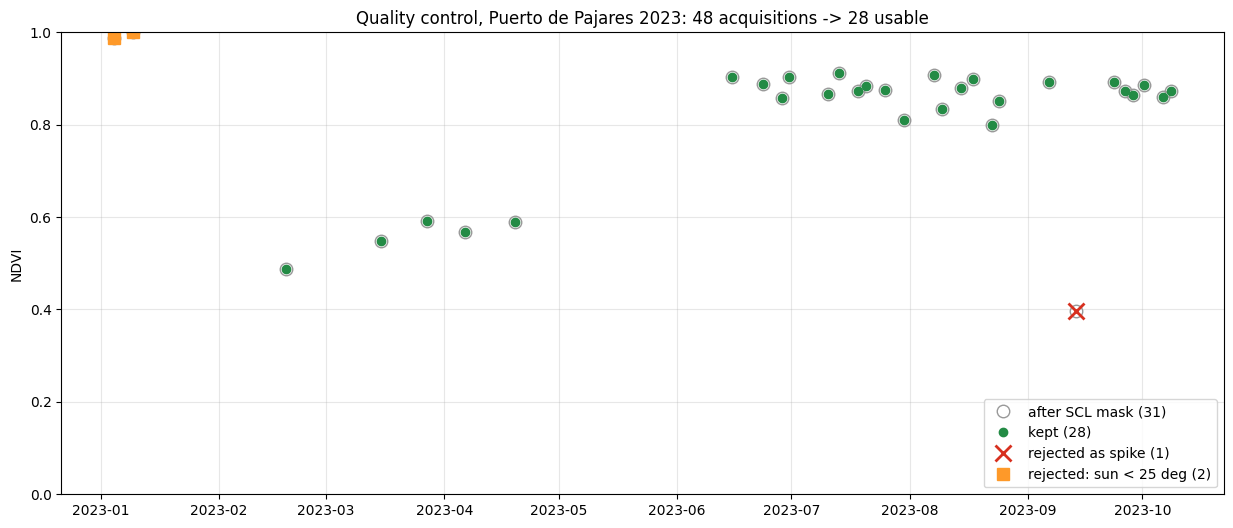

In [ ]:
# One figure showing the fate of every observation. Without this it is
# impossible to tell an empty period from a period with no valid data.

kept = filtered
rejected_spike = raw.where(raw.notnull() & despiked.isnull())
rejected_sun = despiked.where(despiked.notnull() & filtered.isnull())

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 6)

# All observations that survived the SCL mask, drawn first and large
# enough to remain visible underneath.
ax.plot(raw.time, raw.values, marker='o', markersize=9, linestyle='none',
        markerfacecolor='none', markeredgecolor='#999999',
        label=f'after SCL mask ({int(raw.notnull().sum())})')

ax.plot(kept.time, kept.values, marker='o', markersize=6, linestyle='none',
        color='#238b45', label=f'kept ({int(kept.notnull().sum())})')

ax.plot(rejected_spike.time, rejected_spike.values, marker='x', markersize=11,
        linestyle='none', color='#d7301f', markeredgewidth=2,
        label=f'rejected as spike ({int(rejected_spike.notnull().sum())})')

ax.plot(rejected_sun.time, rejected_sun.values, marker='s', markersize=8,
        linestyle='none', color='#fe9929',
        label=f'rejected: sun < {MIN_SUN_ELEVATION} deg '
              f'({int(rejected_sun.notnull().sum())})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.set_ylim(0, 1)
ax.set_ylabel('NDVI')
ax.set_title(f'Quality control, Puerto de Pajares {YEAR}: '
             f'{len(raw)} acquisitions -> {int(kept.notnull().sum())} usable')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

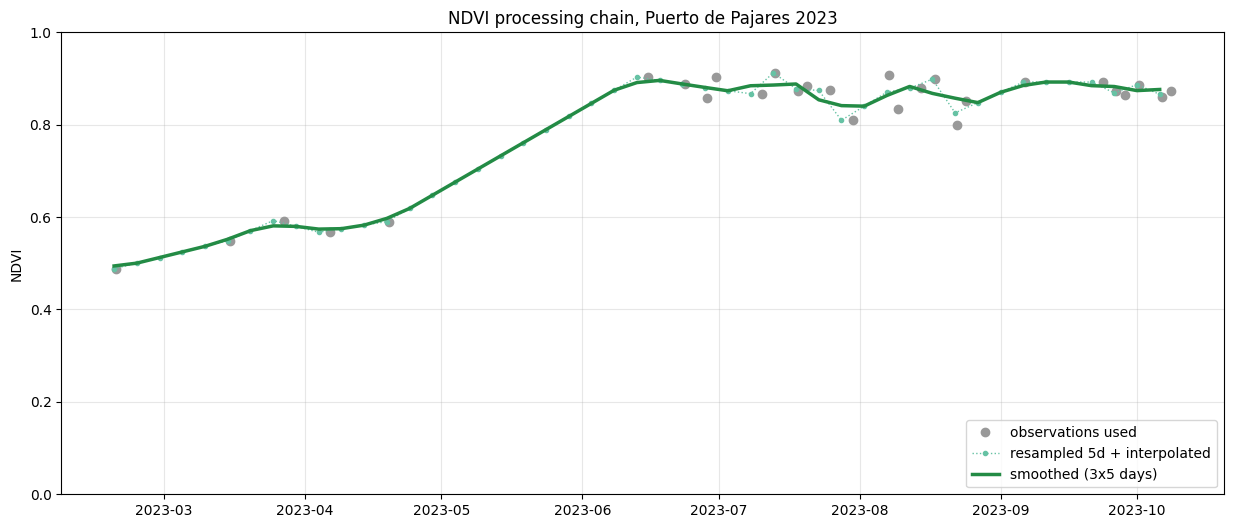

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 6)

ax.plot(kept.time, kept.values, marker='o', markersize=6, linestyle='none',
        color='#999999', label='observations used')

ax.plot(interpolated.time, interpolated.values, marker='.', markersize=6,
        linestyle=':', linewidth=1, color='#66c2a4',
        label=f'resampled {RESAMPLE_FREQ} + interpolated')

ax.plot(smoothed.time, smoothed.values, marker='', linewidth=2.5,
        color='#238b45', label=f'smoothed ({SMOOTH_WINDOW}x5 days)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.set_ylim(0, 1)
ax.set_ylabel('NDVI')
ax.set_title(f'NDVI processing chain, Puerto de Pajares {YEAR}')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

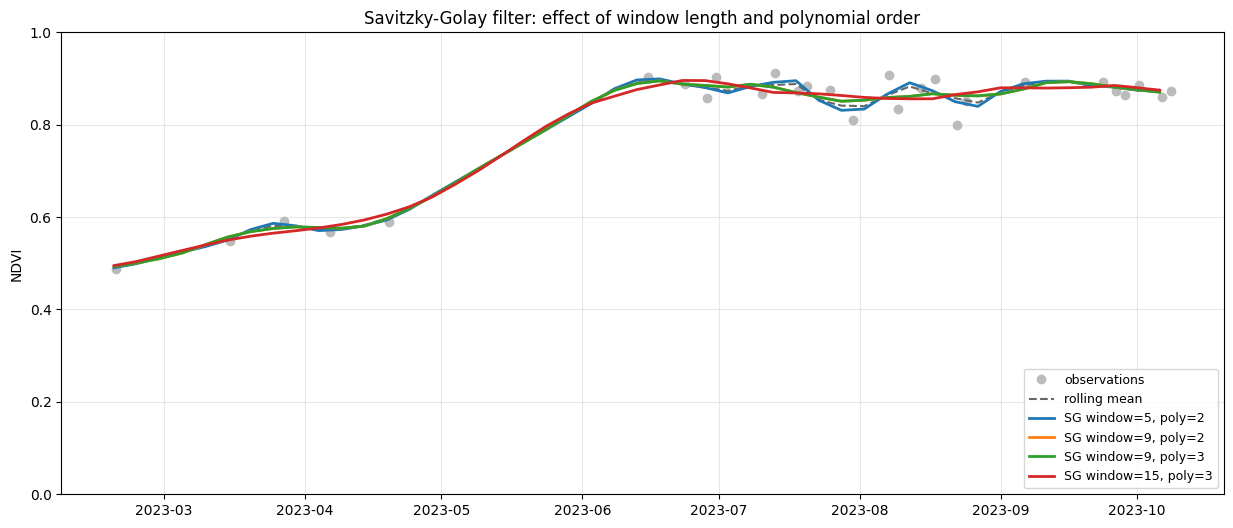

In [ ]:
# Savitzky-Golay fits a low-order polynomial inside a sliding window and
# takes its value at the centre. Unlike a moving average it preserves the
# height and timing of peaks, which matters for phenology: a rolling mean
# flattens the seasonal maximum and shifts the green-up date.
#
# The filter cannot cross gaps, so it runs on the interpolated series and
# the result is masked back to the periods that actually hold data.

valid = interpolated.notnull()
sg_input = interpolated.ffill('time').bfill('time')   # internal only

timestamps = sg_input.time.values
sg_input = sg_input.copy()
sg_input.coords['time'] = np.arange(len(timestamps))

results = {}
for window_length, polyorder in [(5, 2), (9, 2), (9, 3), (15, 3)]:
    out = xrs.savgol_filter(sg_input, window_length=window_length,
                            polyorder=polyorder, mode='nearest', dim='time')
    out.coords['time'] = timestamps
    results[f'window={window_length}, poly={polyorder}'] = out.where(valid)

sg_input.coords['time'] = timestamps

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 6)

ax.plot(kept.time, kept.values, marker='o', markersize=6, linestyle='none',
        color='#bbbbbb', label='observations')
ax.plot(smoothed.time, smoothed.values, linewidth=1.5, linestyle='--',
        color='#666666', label='rolling mean')

for label, series in results.items():
    ax.plot(series.time, series.values, linewidth=2, label=f'SG {label}')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.set_ylim(0, 1)
ax.set_ylabel('NDVI')
ax.set_title('Savitzky-Golay filter: effect of window length and polynomial order')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.show()

In [ ]:
df = pd.DataFrame({
    'date': pd.to_datetime(smoothed.time.values),
    'ndvi_smoothed': smoothed.values,
    'ndvi_interpolated': interpolated.values,
})
df['has_observation'] = interpolated.notnull().values

out_path = os.path.join(output_folder, f'ndvi_pajares_{YEAR}.csv')
df.to_csv(out_path, index=False)
print(f'Wrote {out_path}   ({len(df)} rows, '
      f'{int(df["has_observation"].sum())} with data)')

Wrote /content/drive/MyDrive/python-remote-sensing/ndvi_pajares_2023.csv   (72 rows, 47 with data)
